# Insurance Documents Retrieval Testing

This notebook helps you test and explore your Qdrant vector database.

**What you can do:**
- Connect to Qdrant and inspect collections
- Test semantic search queries
- Compare results across different embedding models
- Visualize chunks and metadata
- Debug retrieval quality

## 1. Setup & Connection

In [1]:
import sys
sys.path.append('..')
from qdrant_client import QdrantClient
from qdrant_client.models import Filter, FieldCondition, MatchValue
from langchain_openai import OpenAIEmbeddings
from langchain_qdrant import QdrantVectorStore, RetrievalMode
from src.config import QDRANT_HOST, OPENAI_API_KEY, OPENROUTER_API_KEY
import pandas as pd
import json
from pprint import pprint

print(f"✅ Connecting to Qdrant at: {QDRANT_HOST}")

/Users/rogier/dev/joho/advies_agent/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Connecting to Qdrant at: http://localhost:6333


In [2]:
# Initialize Qdrant client
client = QdrantClient(url=QDRANT_HOST)

# List all collections
collections = client.get_collections()
print("\n📊 Available Collections:")
print("=" * 70)

for col in collections.collections:
    info = client.get_collection(col.name)
    
    # Handle None values (happens with named vectors in hybrid mode)
    points = info.points_count if info.points_count is not None else 0
    vectors = info.vectors_count if info.vectors_count is not None else 0
    
    print(f"  • {col.name}")
    print(f"    Points: {points:,}")
    
    # In hybrid mode, vectors are named (dense/sparse), so vectors_count may be 0
    if vectors == 0 and points > 0:
        print(f"    Vectors: Named vectors (hybrid retrieval)")
    else:
        print(f"    Vectors: {vectors:,}")
    print()

ResponseHandlingException: [Errno 61] Connection refused

In [3]:
# List all collections
collections = client.get_collections()
print("\n📊 Available Collections:")
print("=" * 70)

for col in collections.collections:
    info = client.get_collection(col.name)
    
    # Gebruik een fallback waarde (0) als de count None is
    points = info.points_count if info.points_count is not None else 0
    vectors = info.vectors_count if info.vectors_count is not None else 0
    
    print(f"  • {col.name}")
    print(f"    Points: {points:,}")
    print(f"    Vectors: {vectors:,}")
    print()


📊 Available Collections:
  • insurance_docs_qwen_qwen3-embedding-8b
    Points: 4,589
    Vectors: 0

  • insurance_docs_text-embedding-3-large
    Points: 4,589
    Vectors: 0



## 2. Select Collection to Test

In [4]:
# Choose which collection to test (change this to your collection name)
COLLECTION_OPENAI_NAME = "insurance_docs_text-embedding-3-large"
COLLECTION_QWEN_NAME = "insurance_docs_qwen_qwen3-embedding-8b"

# Get collection info
try:
    info = client.get_collection(COLLECTION_OPENAI_NAME)
    print(f"✅ Using collection: {COLLECTION_OPENAI_NAME}")
    print(f"   Total chunks: {info.points_count:,}")
except Exception as e:
    print(f"❌ Collection not found: {COLLECTION_OPENAI_NAME}")
    print(f"   Available collections: {[c.name for c in collections.collections]}")

✅ Using collection: insurance_docs_text-embedding-3-large
   Total chunks: 4,589


### Verify Hybrid Retrieval Setup

When using hybrid retrieval, Qdrant uses **Named Vectors**:
- `dense` → Your semantic embeddings (OpenAI)
- `sparse` → BM25 keyword embeddings

This is why `vectors_count = 0` above - there's no unnamed default vector!

In [5]:
# Check collection configuration (vectors setup)
info = client.get_collection(COLLECTION_OPENAI_NAME)

print("📊 Collection Configuration:")
print("=" * 70)
print(f"Vectors config: {info.config.params.vectors}")
print(f"Sparse vectors config: {info.config.params.sparse_vectors}")
print()
print("💡 Note: This collection uses Named Vectors (hybrid retrieval)")
print("   - 'dense': Semantic embeddings (3072 dimensions)")
print("   - 'sparse': BM25 keyword matching")
print("   - vectors_count = 0 is expected (no unnamed vector)")

📊 Collection Configuration:
Vectors config: {'dense': VectorParams(size=3072, distance=<Distance.COSINE: 'Cosine'>, hnsw_config=None, quantization_config=None, on_disk=None, datatype=None, multivector_config=None)}
Sparse vectors config: {'sparse': SparseVectorParams(index=SparseIndexParams(full_scan_threshold=None, on_disk=False, datatype=None), modifier=None)}

💡 Note: This collection uses Named Vectors (hybrid retrieval)
   - 'dense': Semantic embeddings (3072 dimensions)
   - 'sparse': BM25 keyword matching
   - vectors_count = 0 is expected (no unnamed vector)


## 3. Inspect Sample Data

In [6]:
# Get sample points to see metadata structure
sample = client.scroll(
    collection_name=COLLECTION_QWEN_NAME,
    limit=5,
    with_payload=True,
    with_vectors=False  # Don't load vectors (too large)
)

print("📄 Sample Chunks:")
print("=" * 70)
for i, point in enumerate(sample[0], 1):
    print(f"\nChunk {i}:")
    print(f"  Insurance: {point.payload.get('metadata', {}).get('insurance_provider', 'N/A')}")
    print(f"  Company: {point.payload.get('metadata', {}).get('company_display_name', 'N/A')}")
    print(f"  Doc Type: {point.payload.get('metadata', {}).get('document_type', 'N/A')}")
    print(f"  Doc Name: {point.payload.get('metadata', {}).get('document_name', 'N/A')}")
    print(f"  Headers: {point.payload.get('metadata', {}).get('header_1', '')} > {point.payload.get('metadata', {}).get('header_2', '')}")
    print(f"  Preview: {point.payload.get('page_content', '')[:150]}...")

📄 Sample Chunks:

Chunk 1:
  Insurance: oom_wib
  Company: OOM WIB
  Doc Type: N/A
  Doc Name: webpage_20260120.md
  Headers: OOM Living Abroad Insurance > 2. Coverage
  Preview: # OOM Living Abroad Insurance
## 2. Coverage
### Key Points per Insurance:
#### 2. SOS

*   SOS is an integral part of the health insurance. If health...

Chunk 2:
  Insurance: International Expat Insurance
  Company: International Expat Insurance
  Doc Type: N/A
  Doc Name: 1 International Expat Insurance - Healthcare Conditions 2026.md
  Headers: COVERAGE AND BENEFITS > BENEFITS
  Preview: # COVERAGE AND BENEFITS
## BENEFITS
### Other Medical Treatment
#### Local ambulance to the nearest hospital

Reimbursement of the Reasonable and Cust...

Chunk 3:
  Insurance: goudse_expat_pakket
  Company: Goudse Expat Package
  Doc Type: N/A
  Doc Name: 0 Instructie bij uw Goudse Expat Pakket  NL + BE.md
  Headers: Instruction for your Goudse Expat Package > 3. What to do if you are pregnant?
  Preview: # Instruction fo

## 4. Setup Embedder for Queries

In [7]:
from langchain_qdrant import FastEmbedSparse

# Initialize dense embedder (must match the model used for indexing)
embeddings_openai = OpenAIEmbeddings(
    model="text-embedding-3-large",
    api_key=OPENAI_API_KEY
)

embeddings_qwen = OpenAIEmbeddings(
    model="qwen/qwen3-embedding-8b",
    api_key=OPENROUTER_API_KEY,
    openai_api_base="https://openrouter.ai/api/v1"
)
# Initialize sparse embedder for hybrid retrieval (BM25)
sparse_embeddings = FastEmbedSparse(
    model_name="Qdrant/bm25"
)

# Create LangChain vector store for easy querying
vector_store_openai = QdrantVectorStore(
    client=client,
    collection_name=COLLECTION_OPENAI_NAME,
    embedding=embeddings_openai,
    sparse_embedding=sparse_embeddings,
    retrieval_mode=RetrievalMode.HYBRID,
    vector_name="dense",  # Specify the name of the dense vector
    sparse_vector_name="sparse",  # Specify the name of the sparse vector
)

vector_store_qwen = QdrantVectorStore(
    client=client,
    collection_name=COLLECTION_QWEN_NAME,
    embedding=embeddings_qwen,
    sparse_embedding=sparse_embeddings,
    retrieval_mode=RetrievalMode.HYBRID,
    vector_name="dense",  # Specify the name of the dense vector
    sparse_vector_name="sparse",  # Specify the name of the sparse vector
)

print("✅ Embedder ready for queries (dense + sparse)")

✅ Embedder ready for queries (dense + sparse)


## 5. Test Queries

In [8]:
def search(query, k=5, filters=None):                                                                                                                                                                            
    """Search with optional metadata filters"""                                                                                                                                                                  
                                                                                                                                                                                                                
    print(f"🔍 Query: {query}")                                                                                                                                                                                  
    if filters:                                                                                                                                                                                                  
        print(f"   Filters: {filters}")                                                                                                                                                                          
    print("=" * 70)                                                                                                                                                                                              
                                                                                                                                                                                                                
    # Convert simple dict filters to Qdrant Filter format                                                                                                                                                        
    if filters:                                                                                                                                                                                                  
        from qdrant_client.models import Filter, FieldCondition, MatchValue                                                                                                                                      
                                                                                                                                                                                                                
        # Build Qdrant filter                                                                                                                                                                                    
        must_conditions = []                                                                                                                                                                                     
        for key, value in filters.items():                                                                                                                                                                       
            must_conditions.append(                                                                                                                                                                              
                FieldCondition(                                                                                                                                                                                  
                    key=f"metadata.{key}",  # Metadata is nested!                                                                                                                                                
                    match=MatchValue(value=value)                                                                                                                                                                
                )                                                                                                                                                                                                
            )                                                                                                                                                                                                    
                                                                                                                                                                                                                
        qdrant_filter = Filter(must=must_conditions)                                                                                                                                                             
                                                                                                                                                                                                      
        results = vector_store_qwen.similarity_search_with_score(                                                                                                                                                     
            query,                                                                                                                                                                                               
            k=k,                                                                                                                                                                                                 
            filter=qdrant_filter  # Use Qdrant Filter object                                                                                                                                                     
        )                                                                                                                                                                                                        
    else:                                                                                                                                                                                                        
        results = vector_store_qwen.similarity_search_with_score(query, k=k)                                                                                                                                          
                                                                                                                                                                                                                
    # Display results                                                                                                                                                                                            
    for i, (doc, score) in enumerate(results, 1):                                                                                                                                                                
        meta = doc.metadata                                                                                                                                                                                      
        print(f"\n{i}. Score: {score:.4f}")                                                                                                                                                                      
        print(f"   Insurance: {meta.get('insurance_provider', 'N/A')}")                                                                                                                                          
        print(f"   Company: {meta.get('company_display_name', 'N/A')}")                                                                                                                                          
        print(f"   Doc Type: {meta.get('document_type', 'N/A')}")                                                                                                                                                
        print(f"   Doc Name: {meta.get('document_name', 'N/A')}")                                                                                                                                                
        print(f"   Headers: {meta.get('header_1', '')} > {meta.get('header_2', '')} > {meta.get('header_3', '')}")                                                                                               
        print(f"   Preview: {doc.page_content[:1000]}...")                                                                                                                                                        
                                                                                                                                                                                                                
    return results 

In [9]:
# Instructie: Focus op de hiërarchie en de dwingende aard van de headers.
instruction = ""

# Query: Een specifieke vraag naar de 'wat' en 'hoe'.
query = "Can i add a work incapacity insurance to my plan?"

# Final Format voor de Embedder:
formatted_input = f"Instruct: {instruction}\nQuery: {query}"
results = search(formatted_input, k=5)

🔍 Query: Instruct: 
Query: Can i add a work incapacity insurance to my plan?

1. Score: 0.5000
   Insurance: goudse_expat_pakket
   Company: Goudse Expat Package
   Doc Type: N/A
   Doc Name: Summary of benefits Individual Expatriate Package 2026.md
   Headers: Summary of Benefits and Premiums 2026 > 2 Medical expenses > 2.1 Coverage
   Preview: # Summary of Benefits and Premiums 2026
## 2 Medical expenses
### 2.1 Coverage
#### Glasses and contact lenses

The reimbursement for glasses and contact lenses. Under the Standard plan, this is Not covered. Under the Optimal plan, this is Not covered. Under the Excellent plan, this covers a maximum of € 150,- per 3 insurance years....

2. Score: 0.5000
   Insurance: International Expat Insurance
   Company: International Expat Insurance
   Doc Type: N/A
   Doc Name: 0 Instruction International Expat Insurance.md
   Headers: Instruction for your International Expat Insurance > 4. Adding an insured person to your policy > 4.2 Incapacity to work


In [10]:
# Test Query 2: Search with filter (specific insurance)
results = search(
    "What should i consider when changing the coverage of my insurance?",
    k=5,
    filters={"insurance_provider": "goudse_expat_pakket"}
)

🔍 Query: What should i consider when changing the coverage of my insurance?
   Filters: {'insurance_provider': 'goudse_expat_pakket'}

1. Score: 0.5000
   Insurance: goudse_expat_pakket
   Company: Goudse Expat Package
   Doc Type: N/A
   Doc Name: Summary of benefits Individual Expatriate Package 2026.md
   Headers: Summary of Benefits and Premiums 2026 > 2 Medical expenses > 
   Preview: # Summary of Benefits and Premiums 2026
## 2 Medical expenses

This chapter defines the parameters of medical coverage, including maximum insured amounts based on age and region, and the specific benefits provided across different plans....

2. Score: 0.5000
   Insurance: goudse_expat_pakket
   Company: Goudse Expat Package
   Doc Type: N/A
   Doc Name: 0 Instructie bij uw Goudse Expat Pakket  NL + BE.md
   Headers: Instruction for your Goudse Expat Package > 4. Changing health insurance coverage > 
   Preview: # Instruction for your Goudse Expat Package
## 4. Changing health insurance coverage

If y

In [11]:
# Test Query 3: Search in specific document type
results = search(
    "premium cost",
    k=5,
    filters={"document_type": "premiums"}
)

🔍 Query: premium cost
   Filters: {'document_type': 'premiums'}


In [12]:
# Test Query 4: Search only webpages (latest info)
results = search(
    "contact information customer service",
    k=5,
    filters={"is_webpage": True}
)

🔍 Query: contact information customer service
   Filters: {'is_webpage': True}

1. Score: 0.5000
   Insurance: cigna_global_care
   Company: Cigna Global Care
   Doc Type: N/A
   Doc Name: webpage_20260120.md
   Headers: Cigna Global Health > 5. Services After the Insurance Has Started > Claiming Costs
   Preview: # Cigna Global Health
## 5. Services After the Insurance Has Started
### Claiming Costs

*   After being accepted by Cigna for the insurance, you will receive login details for your personal online environment where you can find your coverage information.
*   You can choose to pay medical bills yourself and be reimbursed by Cigna afterward, or Cigna also offers the option to email them unpaid bills, after which Cigna arranges payment with the healthcare provider.  
More information can be found in the Customer Guide....

2. Score: 0.5000
   Insurance: International Expat Insurance
   Company: International Expat Insurance
   Doc Type: N/A
   Doc Name: webpage_20260120.md
   H

## 6. Compare Different Insurances

In [13]:
# Compare the same query across different insurance providers
query = "What are the exclusions?"
insurances = ["goudse_expat_pakket", "allianz_care", "cigna_global_care"]

print(f"🔍 Comparing query: '{query}'\n")
print("=" * 70)

for insurance in insurances:
    print(f"\n📋 {insurance.replace('_', ' ').title()}:")
    print("-" * 70)
    
    try:
        results = vector_store.similarity_search_with_score(
            query,
            k=3,
            filter={"insurance_provider": insurance}
        )
        
        for i, (doc, score) in enumerate(results, 1):
            print(f"  {i}. Score: {score:.4f}")
            print(f"     {doc.page_content[:150]}...\n")
    except Exception as e:
        print(f"  ❌ No results for {insurance}")

🔍 Comparing query: 'What are the exclusions?'


📋 Goudse Expat Pakket:
----------------------------------------------------------------------
  ❌ No results for goudse_expat_pakket

📋 Allianz Care:
----------------------------------------------------------------------
  ❌ No results for allianz_care

📋 Cigna Global Care:
----------------------------------------------------------------------
  ❌ No results for cigna_global_care


## 7. Visualize Chunk Distribution

In [14]:
!uv add seaborn

Resolved 180 packages in 8ms
Audited 175 packages in 32ms


NameError: name 'df' is not defined

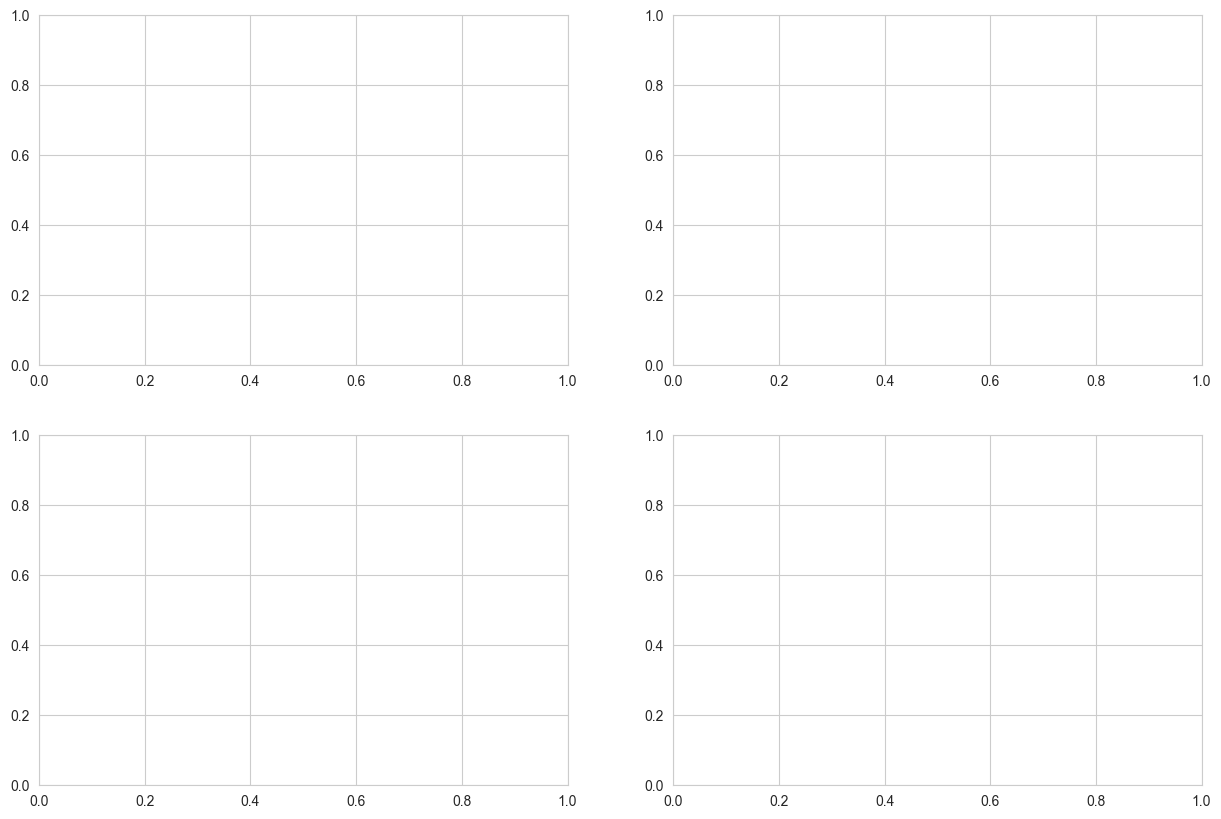

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Plot 1: Chunks per insurance
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Insurance distribution
df['insurance'].value_counts().plot(kind='barh', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Chunks per Insurance Provider', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Number of Chunks')

# Document type distribution
df['doc_type'].value_counts().plot(kind='bar', ax=axes[0, 1], color='lightcoral')
axes[0, 1].set_title('Chunks per Document Type', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Document Type')
axes[0, 1].set_ylabel('Number of Chunks')
axes[0, 1].tick_params(axis='x', rotation=45)

# Chunk size distribution
df['chunk_length'].hist(bins=50, ax=axes[1, 0], color='lightgreen', edgecolor='black')
axes[1, 0].set_title('Chunk Size Distribution', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Chunk Length (characters)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].axvline(df['chunk_length'].mean(), color='red', linestyle='--', label='Mean')
axes[1, 0].legend()

# Webpage vs regular docs
df['is_webpage'].value_counts().plot(kind='pie', ax=axes[1, 1], autopct='%1.1f%%', colors=['lightblue', 'orange'])
axes[1, 1].set_title('Webpage vs Regular Documents', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('')

plt.tight_layout()
plt.show()

print(f"\n📊 Total Chunks: {len(df):,}")
print(f"📊 Average Chunk Size: {df['chunk_length'].mean():.0f} characters")
print(f"📊 Number of Insurance Providers: {df['insurance'].nunique()}")

## 8. Investigate Specific Chunks

In [ ]:
# Find chunks from a specific document
insurance = "goudse_expat_pakket"
doc_type = "conditions"

chunks = client.scroll(
    collection_name=COLLECTION_NAME,
    scroll_filter=Filter(
        must=[
            FieldCondition(key="metadata.insurance_provider", match=MatchValue(value=insurance)),
            FieldCondition(key="metadata.document_type", match=MatchValue(value=doc_type)),
        ]
    ),
    limit=100,
    with_payload=True,
    with_vectors=False
)

print(f"📄 Found {len(chunks[0])} chunks for {insurance} - {doc_type}\n")
print("=" * 70)

for i, chunk in enumerate(chunks[0][:5], 1):
    meta = chunk.payload.get('metadata', {})
    content = chunk.payload.get('page_content', '')
    
    print(f"\nChunk {i}:")
    print(f"  Document: {meta.get('document_name', 'N/A')}")
    print(f"  Headers: {meta.get('header_1', '')} > {meta.get('header_2', '')} > {meta.get('header_3', '')}")
    print(f"  Chunk Index: {meta.get('chunk_index', 'N/A')}")
    print(f"  Length: {len(content)} chars")
    print(f"  Content Preview:\n    {content[:300]}...")
    print("-" * 70)

📄 Found 100 chunks for goudse_expat_pakket - conditions


Chunk 1:
  Document: EN 2025 - Goudse Expat Individual -  Conditions  Medical Expenses 6.0.md
  Headers: Individual Expatriate Package: Medical Expenses insurance > 2. What right of reimbursement does the insured have with the Standard, Optimal and Excellent cover? > 2.4 Inpatient rehabilitation
  Chunk Index: N/A
  Length: 1141 chars
  Content Preview:
    # Individual Expatriate Package: Medical Expenses insurance
## 2. What right of reimbursement does the insured have with the Standard, Optimal and Excellent cover?
### 2.4 Inpatient rehabilitation

### 2.4 Inpatient rehabilitation  
- **What do we reimburse?**
- The costs for clinical rehabilitation...
----------------------------------------------------------------------

Chunk 2:
  Document: EN 2025 - Goudse Expat Individual - General Terms and Conditions 3.0.md
  Headers: 3. How does the claim settlement work? > 3.2 What information is needed to help you or to handle the r

## 9. Debug: Raw Qdrant Search

In [ ]:
# Low-level Qdrant search (useful for debugging)
query = "pregnancy coverage"

# Get query embedding
query_vector = embeddings.embed_query(query)

print(f"Query: {query}")
print(f"Embedding dimension: {len(query_vector)}")
print(f"Embedding preview: {query_vector[:5]}...\n")

# Search directly with Qdrant client
# Note: For hybrid collections, specify vector_name="dense"
results = client.search(
    collection_name=COLLECTION_NAME,
    query_vector=("dense", query_vector),  # Use named vector
    limit=5,
    with_payload=True
)

print("Raw Qdrant Results:")
print("=" * 70)
for i, hit in enumerate(results, 1):
    print(f"\n{i}. Score: {hit.score:.4f}")
    print(f"   ID: {hit.id}")
    print(f"   Metadata: {json.dumps(hit.payload.get('metadata', {}), indent=2)}")
    print(f"   Content: {hit.payload.get('page_content', '')[:150]}...")

Query: pregnancy coverage
Embedding dimension: 3072
Embedding preview: [-0.024881791323423386, -0.008216174319386482, -0.004972038324922323, 0.020043665543198586, -0.000312372314510867]...

Raw Qdrant Results:

1. Score: 0.6461
   ID: 79d5b67a-8fdd-4224-a9f0-21ac49fbbc87
   Metadata: {
  "insurance_provider": "goudse_ngo_zendelingen",
  "company_display_name": "Goudse NGO Zendelingen",
  "document_type": "premiums",
  "document_name": "Goudse NGO Zendelingen Premie-Dekkingsoverzicht 2026.md",
  "version_date": null,
  "is_webpage": false,
  "filepath": "data/documents/goudse_ngo_zendelingen/Goudse NGO Zendelingen Premie-Dekkingsoverzicht 2026.md",
  "document_id": "da16b7a443c8db63",
  "ingestion_timestamp": "2026-01-20T16:07:37.809248",
  "content_hash": "7ddd941612bfc2d85ec051566e52dd28c8a861a14512fe800fdee4c535a17f49",
  "header_1": "Zendelingenpakket Premium and Coverage Overview 2026",
  "header_2": "1. Medical Costs",
  "header_4": "Pregnancy and childbirth in the first 9 months"

/var/folders/3d/1m2d9jp14bx4gh8178nvvbf00000gn/T/ipykernel_97599/2869936407.py:13: DeprecationWarning: `search` method is deprecated and will be removed in the future. Use `query_points` instead.
  results = client.search(


## 10. Compare Models (if you indexed with multiple models)

In [ ]:
# Definieer de configuratie per model voor de vergelijking
model_configs = [
    {
        "name": "OpenAI (text-embedding-3-large)",
        "collection": COLLECTION_OPENAI_NAME,
        "embedding": embeddings_openai
    },
    {
        "name": "Qwen (qwen3-embedding-8b)",
        "collection": COLLECTION_QWEN_NAME,
        "embedding": embeddings_qwen
    }
]

query = "what is the right of the company in applying new policies and terms?"

print(f"🔍 Comparing hybrid query across models: '{query}'\n")
print("=" * 80)

for config in model_configs:
    col_name = config["collection"]
    model_label = config["name"]
    
    try:
        # Valideer of de collectie bestaat in Qdrant
        client.get_collection(col_name)
        
        print(f"\n📊 Model: {model_label}")
        print("-" * 80)
        
        # Initialiseer de vector store specifiek voor dit model
        # We hergebruiken de sparse_embeddings (BM25) voor beide
        vs = QdrantVectorStore(
            client=client,
            collection_name=col_name,
            embedding=config["embedding"],
            sparse_embedding=sparse_embeddings,
            retrieval_mode=RetrievalMode.HYBRID,
            vector_name="dense",
            sparse_vector_name="sparse"
        )
        
        # Voer de hybride zoekopdracht uit
        results = vs.similarity_search_with_score(query, k=5)
        
        if not results:
            print("  ∅ Geen resultaten gevonden.")
        
        for i, (doc, score) in enumerate(results, 1):
            provider = doc.metadata.get('insurance_provider', 'N/A')
            content_preview = doc.page_content.replace('\n', ' ')[:500]
            
            print(f"  {i}. Score: {score:.4f}")
            print(f"     Provider: {provider}")
            print(f"     Preview:  {content_preview}...\n")
            
    except Exception as e:
        print(f"  ⚠️  Fout bij verwerken van collectie '{col_name}': {str(e)}")

🔍 Comparing hybrid query across models: 'what is the right of the company in applying new policies and terms?'


📊 Model: OpenAI (text-embedding-3-large)
--------------------------------------------------------------------------------
  1. Score: 0.5000
     Provider: cigna_close_care
     Preview:  ### 15. Who can enforce this policy   Only we and you have legal rights in connection with this policy. A person who is not a party to this policy has no right under the Contracts (Rights of Third Parties) Act 1999 to enforce any term of this contract but this does not affect any right or remedy of a third party which exists or is available apart from that Act....

  2. Score: 0.5000
     Provider: goudse_ngo_zendelingen
     Preview:  # Article 6: Personal accident ## 6.13 Amendments  **6.13.3 Consequence of not or not timely reporting** If the policyholder fails to timely report any alterations of risk mentioned under Article 6.13.1, in case of a right to payment the following will apply:

## Tips & Tricks

### Investigation Tips:

1. **Check chunk quality:**
   - Look at `chunk_length` distribution - too small/large?
   - Verify headers are preserved in metadata
   - Check if sub-chunks have proper context

2. **Test different queries:**
   - Specific: "pregnancy complications coverage"
   - General: "what is covered"
   - Edge cases: "repatriation", "SOS"

3. **Use filters to debug:**
   - Filter by insurance to compare coverage
   - Filter by doc_type to check structure
   - Filter by is_webpage for latest info

4. **Compare embedding models:**
   - Index with multiple models (different collections)
   - Run same query on each
   - Compare average scores and relevance

### Visualization Ideas:

1. **Heatmap:** Query performance per insurance
2. **Word cloud:** Most common terms in chunks
3. **Scatter:** Chunk size vs score for a query
4. **Network:** Document relationships based on similarity

### Troubleshooting:

- **Low scores (< 0.5):** Query might be too vague or not in corpus
- **Wrong results:** Check if filters are correct
- **Missing data:** Verify insurance name in filters matches exactly
- **Slow queries:** Consider reducing `k` or using filters

### Next Steps:

1. Save good test queries for evaluation
2. Create a test set of queries with expected results
3. Benchmark different chunking strategies
4. Test with real user questions